# 은행 고객 이탈 예측 모델 실습

`생성형AI 기반 모델개발 실습.pdf` 의 Practice #1~#3 를 그대로 코드로 옮긴 노트북입니다.
셀을 위에서부터 순서대로 실행하면 모델 학습 -> 저장(.pkl) -> 신규 데이터 예측까지 끝납니다.

필요 파일 (같은 폴더에 위치): `bank_churn_train.csv`, `bank_churn_new.csv`

In [3]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

## Practice #1 - ML 모델 학습

조건: 목표변수 `Exited`, 알고리즘 Random Forest, 제외 컬럼 `CustomerId`/`Surname`, Train 60% / Validation 20% / Test 20%

In [4]:
df = pd.read_csv("bank_churn_train.csv")
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,baseDate,accountOpeningDate
0,15649487,Sal,578,Germany,Female,38,113150.44,2,1,0,176712.59,1,2/1/2026,4/6/2021
1,15694272,Nkemakolam,673,France,Male,30,64097.75,1,1,1,77783.35,0,2/1/2026,11/28/2024
2,15805955,L?,638,France,Female,48,138333.03,1,1,1,NaN,0,2/1/2026,12/8/2015
3,15676242,Artemova,632,Spain,Male,31,136556.44,1,1,0,82152.83,1,2/1/2026,5/2/2022
4,15756820,Fleming,655,France,Female,26,106198.50,1,0,1,32020.42,0,2/1/2026,10/30/2018


In [5]:
# 날짜 컬럼 -> 계좌 보유 기간(년)으로 변환 (baseDate, accountOpeningDate 자체는 모델에 못 씀)
def add_tenure(frame):
    frame = frame.copy()
    base = pd.to_datetime(frame["baseDate"])
    opened = pd.to_datetime(frame["accountOpeningDate"])
    frame["tenure_years"] = (base - opened).dt.days / 365.25
    return frame.drop(columns=["baseDate", "accountOpeningDate"])

df = add_tenure(df)

TARGET = "Exited"
DROP_COLS = ["CustomerId", "Surname"]

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

cat_cols = ["Geography", "Gender"]
num_cols = [c for c in X.columns if c not in cat_cols]
print("수치형:", num_cols)
print("범주형:", cat_cols)

수치형: ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'tenure_years']
범주형: ['Geography', 'Gender']


In [6]:
# Train 60% / Validation 20% / Test 20% (Exited 비율 유지 - stratify)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print(f"Train: {len(X_train)}  Validation: {len(X_val)}  Test: {len(X_test)}")

Train: 67  Validation: 22  Test: 23


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'IsActiveMember','EstimatedSalary', 'tenure_years']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [8]:
def evaluate(name, X_part, y_part):
    pred = model.predict(X_part)
    proba = model.predict_proba(X_part)[:, 1]
    return {
        "Set": name,
        "Accuracy": accuracy_score(y_part, pred),
        "F1": f1_score(y_part, pred),
        "AUC": roc_auc_score(y_part, proba),
    }

metrics = pd.DataFrame([
    evaluate("Train", X_train, y_train),
    evaluate("Validation", X_val, y_val),
    evaluate("Test", X_test, y_test),
]).set_index("Set")
metrics

,Accuracy,F1,AUC
Set,,,
Train,1.000000,1.000000,1.000000
Validation,0.772727,0.444444,0.705882
Test,0.782609,0.285714,0.784314


In [9]:
# 변수 중요도
feature_names = model.named_steps["preprocess"].get_feature_names_out()
importances = model.named_steps["clf"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importance_df

,feature,importance
0,num__Age,0.257542
1,num__EstimatedSalary,0.135442
2,num__tenure_years,0.132765
3,num__CreditScore,0.110960
4,num__NumOfProducts,0.105604
5,num__Balance,0.100136
6,num__IsActiveMember,0.029287
7,cat__Gender_Male,0.027382
8,cat__Gender_Female,0.027212
9,cat__Geography_Germany,0.023248


/var/folders/0n/_n1pmtys4kx97bxt_2yy7_p80000gn/T/ipykernel_25142/2513136992.py:7: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0n/_n1pmtys4kx97bxt_2yy7_p80000gn/T/ipykernel_25142/2513136992.py:7: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0n/_n1pmtys4kx97bxt_2yy7_p80000gn/T/ipykernel_25142/2513136992.py:7: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0n/_n1pmtys4kx97bxt_2yy7_p80000gn/T/ipykernel_25142/2513136992.py:7: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0n/_n1pmtys4kx97bxt_2yy7_p80000gn/T/ipykernel_25142/2513136992.py:7: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/limchaehyeon/Desktop/SKALA/0928-0929-모델 개발 및 

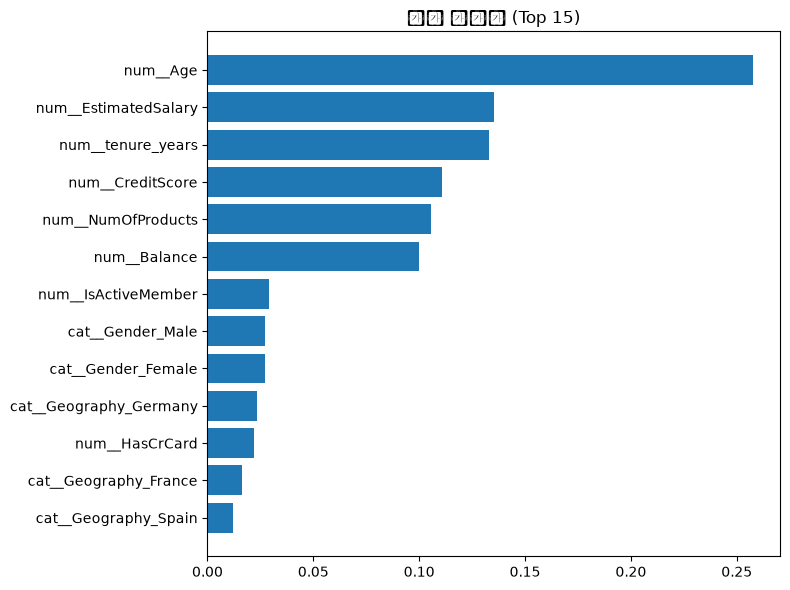

In [10]:
import matplotlib.pyplot as plt

top = importance_df.head(15)
plt.figure(figsize=(8, 6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title("변수 중요도 (Top 15)")
plt.tight_layout()
plt.show()

## Practice #2 - ML 모델 저장

전처리 + 모델이 하나로 묶인 Pipeline 전체를 `bank_churn_model.pkl` 로 저장합니다.

In [11]:
joblib.dump(model, "bank_churn_model.pkl")
print("저장 완료: bank_churn_model.pkl")

저장 완료: bank_churn_model.pkl


## Practice #3 - ML 모델 예측

저장된 `bank_churn_model.pkl` 을 불러와 `bank_churn_new.csv` (Exited 없음) 의 이탈 Score 를 생성합니다.

In [12]:
loaded_model = joblib.load("bank_churn_model.pkl")

new_df = pd.read_csv("bank_churn_new.csv")
new_df_feat = add_tenure(new_df)
new_X = new_df_feat.drop(columns=DROP_COLS)

scores = loaded_model.predict_proba(new_X)[:, 1]

result = new_df[["CustomerId", "Surname"]].copy()
result["Exited_Score"] = scores
result["Exited_Pred"] = (scores >= 0.5).astype(int)

result.to_csv("bank_churn_new_scored.csv", index=False)
result.sort_values("Exited_Score", ascending=False).head(10)

,CustomerId,Surname,Exited_Score,Exited_Pred
54,15635435,White,0.750000,1
63,15625426,Ashbolt,0.740000,1
90,15805260,Wood,0.686667,1
1,15610446,Chinedum,0.660000,1
31,15618936,MacDonald,0.643333,1
39,15810418,T'ang,0.640000,1
19,15752300,Sagese,0.600000,1
93,15651554,Anenechukwu,0.590000,1
12,15756026,Hooper,0.580000,1
96,15764170,Pinto,0.580000,1
